#Upper Confidence Bound Implemantation

*   Goal is to find the best performing advertisement as quickly as possible
while running it online [Value of 'N' can be changed to verify the output]
*  Dataset is used to simulate the best performing advertisement.
*   Every Row is a round that is associated with a user.
*   there are 10 columns denoting 10 different advertisements
*  Each  column contains the reward that is obtained  when the add is selected

*  Each round , we go through all the advertisements and  Identify the advertisement that has to be displayed in that round [highest UCB], based on the UCB formula

*   The advertisement with the highest UCB is selected for that round.
* The algorithm is run for different samplesize to find out how fast it is able detect the one that has higest reward








#Author- Yashas Samaga

###imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

### Datasets

In [2]:
df = pd.read_csv('Ads_CTR_Optimisation.csv')
print(df)
print(df.shape)
# 1- advertisement is clicked by user
#  0 - advertisement is not clicked by user

      Ad 1  Ad 2  Ad 3  Ad 4  Ad 5  Ad 6  Ad 7  Ad 8  Ad 9  Ad 10
0        1     0     0     0     1     0     0     0     1      0
1        0     0     0     0     0     0     0     0     1      0
2        0     0     0     0     0     0     0     0     0      0
3        0     1     0     0     0     0     0     1     0      0
4        0     0     0     0     0     0     0     0     0      0
...    ...   ...   ...   ...   ...   ...   ...   ...   ...    ...
9995     0     0     1     0     0     0     0     1     0      0
9996     0     0     0     0     0     0     0     0     0      0
9997     0     0     0     0     0     0     0     0     0      0
9998     1     0     0     0     0     0     0     1     0      0
9999     0     1     0     0     0     0     0     0     0      0

[10000 rows x 10 columns]
(10000, 10)


###Implementing UCB

In [3]:
#  total users or rounds where we show adds to users

# N= len(df)
N = 500

#  Numbers of advertisement
d= len(df.iloc[0,:].values)



print(N)
print(d)

500
10


In [4]:
import matplotlib.pyplot as plt

def plotGraph(N,ads_selected):
  bins = range(0, 10)  # 0–11 edges
  plt.hist(ads_selected)
  plt.xticks(range(0, 10))  # show 0 to 10 on x-axis
  plt.xlabel("advertisement")
  plt.ylabel("Frequency (Count)")
  plt.title(f"Histogram of advertisement vs Frequency for Sample Size {N}")

  plt.show()

In [5]:
def findBestPerformingAdvertisement(N):
  #  count of i th advertisement  that is shown to users
  numbers_of_selections = [0 for i in range(0,10)]

  # total rewards for i th advertisement when shown to user
  sums_of_reward = [0 for i in range(0,10)]

  ads_selected= []
  total_rewards=0

  for n in  range(0,N):
    ad_selected_per_round=0
    max_upper_bound_per_round=0
    #  traversing through each add to find the mac UCB add.
    for  i in range(0,d):
      if(numbers_of_selections[i] >0):
        average= sums_of_reward[i]/numbers_of_selections[i]
        delta_i= math.sqrt(3/2 * math.log(n+1) /numbers_of_selections[i])
        ucb= average+delta_i
      else:
        #  max UCB , select this
        ucb=1e400

      #  selecting the max UCB add per round
      if(ucb>max_upper_bound_per_round):
        max_upper_bound_per_round=ucb
        ad_selected_per_round=i

    # 'ad_selected_per_round' is the add selected in round 'n'
    ads_selected.append(ad_selected_per_round)
    numbers_of_selections[ad_selected_per_round]=numbers_of_selections[ad_selected_per_round]+1
    reward = int(df.iloc[n,ad_selected_per_round])
    sums_of_reward[ad_selected_per_round] = sums_of_reward[ad_selected_per_round] + reward
    total_rewards= total_rewards+reward

  plotGraph(N,ads_selected)



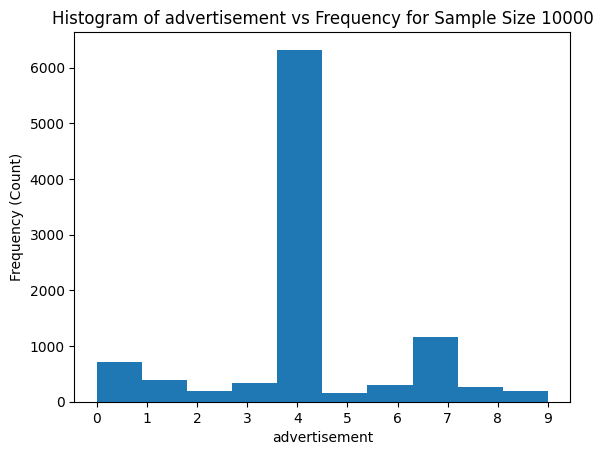

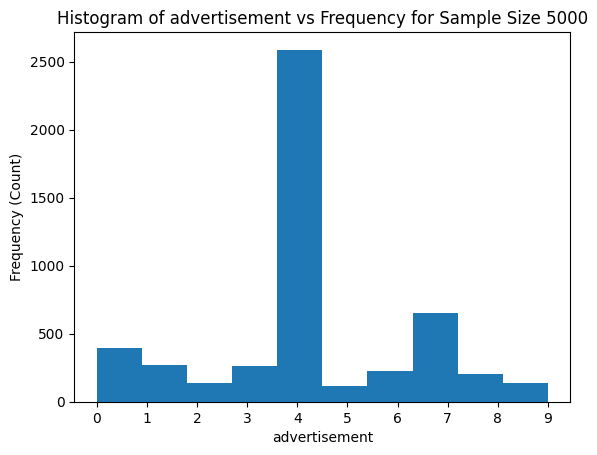

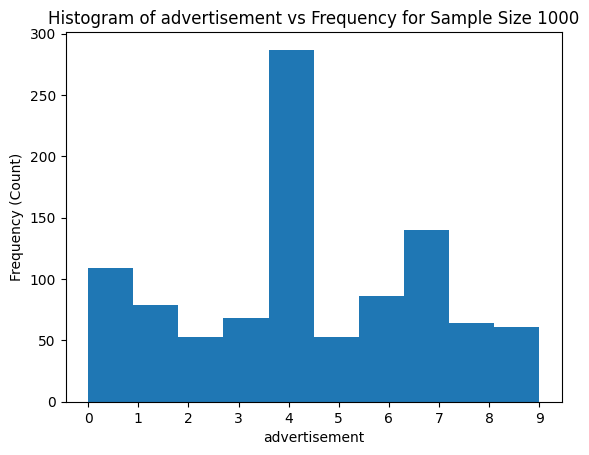

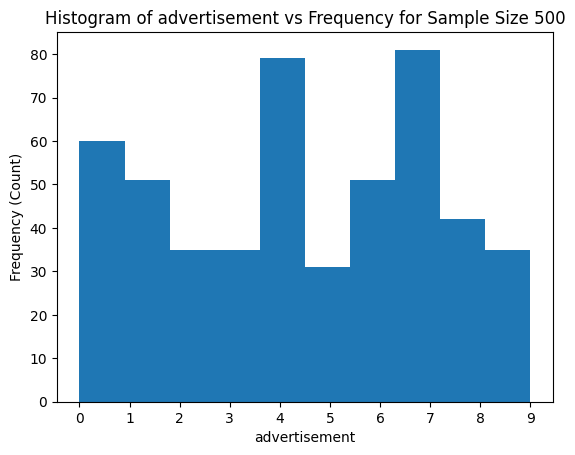

In [6]:
for sampleSize in [len(df),int(len(df)/2), int(len(df)/10), int(len(df)/20)]:
  findBestPerformingAdvertisement(sampleSize)

### conclusion



*   with N= 10000 , best performing advertisement = add Number 4
*    with N= 5000 , best performing advertisement = add Number 4
*  with N= 1000, best performing advertisement = add Number 4
*   with N = 500 , the samoles are not enough for the agent using UCB algorithim to identify the best advertisement



